# Module 1 → Module 2 Bridge + Module 2 POC Training

Runs the trained classifier + EX/MA segmentation models over FIRE (and LongDRScreening)
images, caches real grade/mask/LBS, then runs a short Module 2 GAN training pass using that
real conditioning instead of today's empty-mask/Stage-2 placeholder.

**HE/SE are not trained yet tonight** -- the combined lesion mask fed to Module 2 here is
the union of whatever IS trained (EX + MA); it is not a claim of complete lesion coverage.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import getpass, os
# This repo is PRIVATE -- Colab needs a GitHub Personal Access Token to clone it.
# Create one (once, reusable across all 4 notebooks/sessions) at
# https://github.com/settings/tokens -> "Generate new token (classic)" -> scope: repo.
# Input is hidden; not saved anywhere.
GITHUB_TOKEN = getpass.getpass('GitHub Personal Access Token (repo scope): ')

DRIVE_DATA_DIR = '/content/drive/MyDrive/Thesis_Datasets'  # <-- change if you used a different folder
assert os.path.isdir(DRIVE_DATA_DIR), f"Not found: {DRIVE_DATA_DIR} -- upload the 4 dataset zips there first"


Mounted at /content/drive
GitHub Personal Access Token (repo scope): ··········


In [2]:
# Unzip datasets locally on the Colab VM disk (much faster I/O than reading zips off Drive
# directly). -n skips files that already exist, so this is safe/cheap to re-run.
os.makedirs('/content/data', exist_ok=True)
%cd /content/data
!unzip -q -n "$DRIVE_DATA_DIR/FGADR-Seg-set_Release.zip"
!unzip -q -n "$DRIVE_DATA_DIR/archive.zip" -d IDRiD_dataset_root
!unzip -q -n "$DRIVE_DATA_DIR/FIRE_dataset.zip"
# LongDRScreening_20150209.zip has NO top-level wrapper folder -- without -d it dumps
# FundusImagesNormalized/, README.txt, *.csv straight into /content/data. Force it into a
# named folder so cells 8/9's paths resolve.
!unzip -q -n "$DRIVE_DATA_DIR/LongDRScreening_20150209.zip" -d LongDRScreening_20150209

# archive.zip may unzip with an extra nesting level; normalize so IDRiD_dataset ends up
# directly under /content/data
import glob, shutil
candidates = glob.glob('/content/data/IDRiD_dataset_root/**/IDRiD_dataset', recursive=True)
if candidates and not os.path.isdir('/content/data/IDRiD_dataset'):
    shutil.move(candidates[0], '/content/data/IDRiD_dataset')
print('IDRiD_dataset present:', os.path.isdir('/content/data/IDRiD_dataset'))
print('FIRE Images present :', os.path.isdir('/content/data/FIRE_dataset/FIRE/Images'))
print('LongDR norm present :', os.path.isdir('/content/data/LongDRScreening_20150209/FundusImagesNormalized'))


/content/data
IDRiD_dataset present: True
FIRE Images present : True
LongDR norm present : True


In [3]:
# Clone this repo (private -- uses the token above) and the pinned DRG-Net reference
# implementation. Skips cleanly if already cloned in this runtime.
%cd /content
if not os.path.isdir('/content/M2-DRProgression'):
    !git clone --branch module1-fgadr-poc https://{GITHUB_TOKEN}@github.com/bearawr/M2-DRProgression.git M2-DRProgression
if not os.path.isdir('/content/dr-joint-learning'):
    !git clone https://github.com/DFKI-Interactive-Machine-Learning/dr-joint-learning.git dr-joint-learning
    %cd dr-joint-learning
    !git checkout 0da1bbe885f438390a0e94ec486283d9b21d5547
    %cd /content

# Compatibility patch: DRG-Net's own code (dr_classification/data/transforms.py) still uses
# torchvision.transforms.RandomAffine's old 'fillcolor' kwarg, renamed to 'fill' and fully
# removed in the torchvision version Colab now ships (we deliberately don't install the repo's
# old pinned torchvision -- see notebook 02's install cell -- so this old kwarg name breaks).
# Idempotent: sed -i only changes the file if 'fillcolor' is still present.
!sed -i 's/fillcolor=aug_args.value_fill/fill=aug_args.value_fill/' /content/dr-joint-learning/dr_classification/data/transforms.py

# Same class of issue, in dr_segmentation's transform code (only exercised by notebook 03,
# harmless to run here too): functional.py imports PILLOW_VERSION, removed from Pillow years
# ago; transforms_group.py bare-imports ipdb, a debugger package not installed by default.
# Both would crash the import chain immediately (from transform.transforms_group import *).
!pip install -q ipdb
_func_py = '/content/dr-joint-learning/dr_segmentation/transform/functional.py'
_txt = open(_func_py).read()
_txt = _txt.replace(
    'from PIL import Image, ImageOps, ImageEnhance, PILLOW_VERSION',
    "from PIL import Image, ImageOps, ImageEnhance\nPILLOW_VERSION = '9.0.0'"
)
open(_func_py, 'w').write(_txt)



/content
Cloning into 'M2-DRProgression'...
remote: Enumerating objects: 193, done.
remote: Counting objects: 100% (193/193), done.
remote: Compressing objects: 100% (134/134), done.
remote: Total 193 (delta 98), reused 134 (delta 56), pack-reused 0 (from 0)
Receiving objects: 100% (193/193), 1.10 MiB | 6.04 MiB/s, done.
Resolving deltas: 100% (98/98), done.
Cloning into 'dr-joint-learning'...
remote: Enumerating objects: 283, done.
remote: Counting objects: 100% (283/283), done.
remote: Compressing objects: 100% (187/187), done.
remote: Total 283 (delta 110), reused 249 (delta 88), pack-reused 0 (from 0)
Receiving objects: 100% (283/283), 9.32 MiB | 9.59 MiB/s, done.
Resolving deltas: 100% (110/110), done.
/content/dr-joint-learning
Note: switching to '0da1bbe885f438390a0e94ec486283d9b21d5547'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switc

26134

In [4]:
# Copy DRG-Net's own filtered-label CSV (vendored in our repo) into the local FGADR folder --
# dr_segmentation/utils.py::get_images_fgadr_from_pd reads this file from inside IMAGE_DIR.
# Made robust to zip-nesting variation (some zip tools add/drop the top-level
# FGADR-Seg-set_Release wrapper folder) by locating Seg-set/ wherever it actually landed.
import glob as _glob, os, shutil

_candidates = _glob.glob('/content/data/**/Seg-set', recursive=True)
assert _candidates, (
    'No Seg-set folder found under /content/data. Run: !ls /content/data  and  '
    '!ls "$DRIVE_DATA_DIR"  to check the zip is named exactly FGADR-Seg-set_Release.zip '
    'and actually unzipped in the previous cell.'
)
fgadr_segset_dir = _candidates[0]
print('Found FGADR Seg-set at:', fgadr_segset_dir)

expected = '/content/data/FGADR-Seg-set_Release/Seg-set'
if fgadr_segset_dir != expected:
    os.makedirs(os.path.dirname(expected), exist_ok=True)
    if not os.path.exists(expected):
        os.symlink(fgadr_segset_dir, expected)
    print(f'Normalized path: {expected} -> {fgadr_segset_dir}')

shutil.copy(
    '/content/M2-DRProgression/module1/data/DR_Seg_Grading_Label_Filtered.csv',
    os.path.join(expected, 'DR_Seg_Grading_Label_Filtered.csv')
)
print('done')


Found FGADR Seg-set at: /content/data/Seg-set
Normalized path: /content/data/FGADR-Seg-set_Release/Seg-set -> /content/data/Seg-set
done


In [5]:
%cd /content/M2-DRProgression
!pip install -q segmentation-models-pytorch torchmetrics torch-fidelity


/content/M2-DRProgression
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 7.5 MB/s eta 0:00:00


In [6]:
import os, glob

SEG_DIR   = '/content/drive/MyDrive/Thesis_Datasets/module1_runs/segmentation'
CLS_SAVES = '/content/drive/MyDrive/Thesis_Datasets/module1_runs/classification/fgadr/saves'

print('classifier saves dir:', os.listdir(CLS_SAVES) if os.path.isdir(CLS_SAVES) else 'MISSING -- run notebook 02 first')

# DRG-Net's dr_classification/main.py checkpoint filename isn't pinned in our adapter, so
# discover it: prefer the final-model weights, then best-val, then whatever .pt is newest.
_pref  = ['final_weights.pt', 'best_validation_weights.pt']
_cands = [os.path.join(CLS_SAVES, n) for n in _pref] + sorted(
    glob.glob(os.path.join(CLS_SAVES, '*.pt')), key=os.path.getmtime, reverse=True)
CLS_CKPT = next((p for p in _cands if os.path.isfile(p)), None)
assert CLS_CKPT, f"No classifier .pt in {CLS_SAVES}"

EX_CKPT = os.path.join(SEG_DIR, 'models_FGADR_NO_TATL_ex', 'model_2.pth.tar')
MA_CKPT = os.path.join(SEG_DIR, 'models_FGADR_NO_TATL_ma', 'model_2.pth.tar')
for _p in (CLS_CKPT, EX_CKPT, MA_CKPT):
    assert os.path.isfile(_p), f"missing checkpoint: {_p}"
print('classifier :', CLS_CKPT)
print('EX seg     :', EX_CKPT)
print('MA seg     :', MA_CKPT)

# HE/SE checkpoints -- included automatically once they exist on Drive, omitted otherwise
# (apply_to_progression_data.py leaves a lesion channel out rather than fail if no checkpoint
# is passed for it; see that script's own docstring).
HE_CKPT = os.path.join(SEG_DIR, 'models_FGADR_NO_TATL_he', 'model_2.pth.tar')
SE_CKPT = os.path.join(SEG_DIR, 'models_FGADR_NO_TATL_se', 'model_2.pth.tar')
print('HE seg     :', HE_CKPT if os.path.isfile(HE_CKPT) else 'not trained yet')
print('SE seg     :', SE_CKPT if os.path.isfile(SE_CKPT) else 'not trained yet')

_extra_seg_args = ''
if os.path.isfile(HE_CKPT):
    _extra_seg_args += f' --seg-checkpoint HE="{HE_CKPT}"'
if os.path.isfile(SE_CKPT):
    _extra_seg_args += f' --seg-checkpoint SE="{SE_CKPT}"'

os.makedirs('/content/drive/MyDrive/Thesis_Datasets/module1_cache', exist_ok=True)


classifier saves dir: ['fgadr_poc.yaml', 'epoch_5.pt', 'epoch_10.pt', 'best_validation_weights.pt', 'epoch_15.pt', 'epoch_20.pt', 'final_weights.pt']
classifier : /content/drive/MyDrive/Thesis_Datasets/module1_runs/classification/fgadr/saves/final_weights.pt
EX seg     : /content/drive/MyDrive/Thesis_Datasets/module1_runs/segmentation/models_FGADR_NO_TATL_ex/model_2.pth.tar
MA seg     : /content/drive/MyDrive/Thesis_Datasets/module1_runs/segmentation/models_FGADR_NO_TATL_ma/model_2.pth.tar
HE seg     : /content/drive/MyDrive/Thesis_Datasets/module1_runs/segmentation/models_FGADR_NO_TATL_he/model_2.pth.tar
SE seg     : /content/drive/MyDrive/Thesis_Datasets/module1_runs/segmentation/models_FGADR_NO_TATL_se/model_2.pth.tar


In [7]:
%cd /content/M2-DRProgression/module1
# FIRE_dataset.zip self-wraps -> images land at /content/data/FIRE_dataset/FIRE/Images
# (the old /content/data/FIRE/Images path was wrong and would cache 0 images).
!python apply_to_progression_data.py --images-dir /content/data/FIRE_dataset/FIRE/Images --classifier-checkpoint "{CLS_CKPT}" --seg-checkpoint EX="{EX_CKPT}" --seg-checkpoint MA="{MA_CKPT}"{_extra_seg_args} --out /content/drive/MyDrive/Thesis_Datasets/module1_cache/module1_outputs_fire.pt


/content/M2-DRProgression/module1
✓ A01_1: grade=3 lbs=0.00008 (lesions: ['EX', 'HE', 'MA', 'SE'])
✓ A01_2: grade=3 lbs=0.00000 (lesions: ['EX', 'HE', 'MA', 'SE'])
✓ A02_1: grade=4 lbs=0.00188 (lesions: ['EX', 'HE', 'MA', 'SE'])
✓ A02_2: grade=4 lbs=0.00354 (lesions: ['EX', 'HE', 'MA', 'SE'])
✓ A03_1: grade=4 lbs=0.00188 (lesions: ['EX', 'HE', 'MA', 'SE'])
✓ A03_2: grade=4 lbs=0.00404 (lesions: ['EX', 'HE', 'MA', 'SE'])
✓ A04_1: grade=4 lbs=0.00354 (lesions: ['EX', 'HE', 'MA', 'SE'])
✓ A04_2: grade=4 lbs=0.00404 (lesions: ['EX', 'HE', 'MA', 'SE'])
✓ A05_1: grade=3 lbs=0.00038 (lesions: ['EX', 'HE', 'MA', 'SE'])
✓ A05_2: grade=4 lbs=0.00354 (lesions: ['EX', 'HE', 'MA', 'SE'])
✓ A06_1: grade=3 lbs=0.00038 (lesions: ['EX', 'HE', 'MA', 'SE'])
✓ A06_2: grade=4 lbs=0.00404 (lesions: ['EX', 'HE', 'MA', 'SE'])
✓ A07_1: grade=4 lbs=0.00003 (lesions: ['EX', 'HE', 'MA', 'SE'])
✓ A07_2: grade=4 lbs=0.00000 (lesions: ['EX', 'HE', 'MA', 'SE'])
✓ A08_1: grade=4 lbs=0.00003 (lesions: ['EX', 'HE', 'MA'

In [8]:
# LongDR: cell 2 now unzips into /content/data/LongDRScreening_20150209/ so this path resolves.
!python apply_to_progression_data.py --images-dir /content/data/LongDRScreening_20150209/FundusImagesNormalized --classifier-checkpoint "{CLS_CKPT}" --seg-checkpoint EX="{EX_CKPT}" --seg-checkpoint MA="{MA_CKPT}"{_extra_seg_args} --out /content/drive/MyDrive/Thesis_Datasets/module1_cache/module1_outputs_longdr.pt


✓ eye_001__visit_1_image_1: grade=3 lbs=0.00011 (lesions: ['EX', 'HE', 'MA', 'SE'])
✓ eye_001__visit_1_image_2: grade=3 lbs=0.00000 (lesions: ['EX', 'HE', 'MA', 'SE'])
✓ eye_001__visit_1_image_3: grade=3 lbs=0.00000 (lesions: ['EX', 'HE', 'MA', 'SE'])
✓ eye_001__visit_1_image_4: grade=3 lbs=0.00000 (lesions: ['EX', 'HE', 'MA', 'SE'])
✓ eye_001__visit_2_image_1: grade=3 lbs=0.00000 (lesions: ['EX', 'HE', 'MA', 'SE'])
✓ eye_001__visit_2_image_2: grade=3 lbs=0.00000 (lesions: ['EX', 'HE', 'MA', 'SE'])
✓ eye_001__visit_2_image_3: grade=3 lbs=0.00000 (lesions: ['EX', 'HE', 'MA', 'SE'])
✓ eye_001__visit_2_image_4: grade=3 lbs=0.00000 (lesions: ['EX', 'HE', 'MA', 'SE'])
✓ eye_002__visit_1_image_1: grade=3 lbs=0.00037 (lesions: ['EX', 'HE', 'MA', 'SE'])
✓ eye_002__visit_1_image_2: grade=3 lbs=0.00000 (lesions: ['EX', 'HE', 'MA', 'SE'])
✓ eye_002__visit_1_image_3: grade=3 lbs=0.00000 (lesions: ['EX', 'HE', 'MA', 'SE'])
✓ eye_002__visit_1_image_4: grade=3 lbs=0.00000 (lesions: ['EX', 'HE', 'MA',

In [9]:
%cd /content/M2-DRProgression
# --fire-dir / --longdr-dir MUST be passed: train_module2_poc.py's defaults (./FIRE_dataset,
# ./LongDRScreening_20150209) resolve under /content/M2-DRProgression, where the data isn't.
!python train_module2_poc.py --fire-dir /content/data/FIRE_dataset --longdr-dir /content/data/LongDRScreening_20150209 --fire-module1-cache /content/drive/MyDrive/Thesis_Datasets/module1_cache/module1_outputs_fire.pt --longdr-module1-cache /content/drive/MyDrive/Thesis_Datasets/module1_cache/module1_outputs_longdr.pt --num-epochs 5


/content/M2-DRProgression
Module 2 POC training (real Module 1 conditioning)
Device: cuda
fire_module1_cache_path: /content/drive/MyDrive/Thesis_Datasets/module1_cache/module1_outputs_fire.pt
longdr_module1_cache_path: /content/drive/MyDrive/Thesis_Datasets/module1_cache/module1_outputs_longdr.pt

[1/4] Loading combined dataset (with real Module 1 conditioning where cached)...
✓ Loaded Module 1 cache: 268 images (/content/drive/MyDrive/Thesis_Datasets/module1_cache/module1_outputs_fire.pt)
  Searching: /content/data/FIRE_dataset/FIRE/Images
✓ Found 14 pairs in FIRE Category A
✓ FIRE: 14 pairs
✓ Loaded Module 1 cache: 1120 images (/content/drive/MyDrive/Thesis_Datasets/module1_cache/module1_outputs_longdr.pt)
✓ Found 559 pairs in LongDRScreening (FundusImagesNormalized)
✓ LongDRScreening: 559 pairs
✓ Combined: 573 pairs
✓ Augmented: 2292 effective samples
✓ Real pairs: 573, effective samples: 2292, batches/epoch: 573

[2/4] Initializing models...

[3/4] Training for 5 epochs (POC scale 

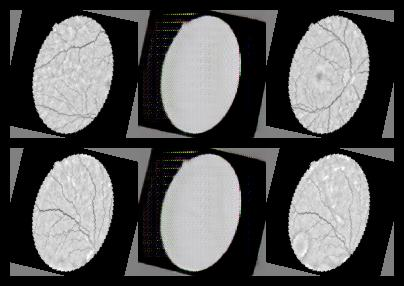

{
  "num_epochs": 5,
  "num_pairs": 573,
  "effective_samples": 2292,
  "g_lr": 0.0002,
  "d_lr": 0.0002,
  "beta1": 0.0,
  "beta2": 0.9,
  "fire_module1_cache_path": "/content/drive/MyDrive/Thesis_Datasets/module1_cache/module1_outputs_fire.pt",
  "longdr_module1_cache_path": "/content/drive/MyDrive/Thesis_Datasets/module1_cache/module1_outputs_longdr.pt",
  "metrics": {
    "psnr": 22.65667152404785,
    "ssim": 0.49715685844421387,
    "fid": 9.640569686889648,
    "n_batches_used": 5
  },
  "total_time_min": 24.249904906749727
}


In [10]:
from IPython.display import Image as IPImage, display
import glob, json, os

samples = sorted(glob.glob('training_samples_poc/epoch_*.jpg'))
if samples:
    display(IPImage(samples[-1]))
else:
    print('No training_samples_poc/epoch_*.jpg found -- cell 9 did not finish. Read its output above.')

rp = 'DRForestGAN-v2/stargan/models_poc/poc_results.json'
print(json.dumps(json.load(open(rp)), indent=2) if os.path.isfile(rp) else f'{rp} not found')


## Honest caveats for the presentation

- Segmentation-driven conditioning covers EX + MA, plus HE + SE automatically once those
  checkpoints exist on Drive (see cell 6) -- no longer EX+MA-only as of this run.
- Module 2's epoch count (5) and optimizer settings here intentionally diverge from
  `train_combined.py`'s existing defaults to match the manuscript's stated Adam
  hyperparameters -- see `train_module2_poc.py`'s module docstring.
- FID/PSNR/SSIM above are from a tiny, short run -- not a claim of matching DRForecastGAN's
  published benchmark (FID 27.3 / PSNR 25.3 / SSIM 0.93).
- Module 2's AdaIN stage-conditioning + autoregressive cascade generation (the manuscript's
  claimed core original contribution) is not implemented yet -- this run uses the existing
  plain conditional GAN in `DRForestGAN-v2/`.